# <center>Project: Bayesian Analysis of Mushroom Preservation

## 1. Introduction 

This applied Bayesian analysis project aims to model the impact of **storage temperature** on the **spoilage rate** of harvested oyster mushrooms, using an approach based on Bayesian logistic regression.


### Project Goal

The main objective is to estimate the parameters $(\alpha, \beta)$ of the probabilistic model that links the storage temperature $x_i$ to the probability $p_i$ that a mushroom spoils. This relationship is defined by the **logistic (or sigmoid) function**:

$$p_i = \text{sigm}(\alpha + \beta x_i) = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}$$


### Probabilistic Model Structure

The complete model combines a **Binomial Likelihood** with **Gaussian Priors** on the parameters, defining the full probabilistic model:

##### Likelihood

Assuming the outcomes of the $n_i$ mushrooms within each group $i$ are **independent** , the number of spoiled mushrooms $y_i$ out of $n_i$ total at a given temperature $x_i$ is modeled with a **Binomial distribution**:

$$y_i | \alpha, \beta \sim \text{Bin}(n_i, p_i)$$

##### Prior

The model parameters $\theta = [\begin{matrix}\alpha & \beta\end{matrix}]^{\top}$ are assigned a **Gaussian (Normal) prior probability distribution**[cite: 1866]:

* **Intercept Parameter ($\alpha$):**
    $$\alpha \sim \mathcal{N}(\mu_{\alpha}, \sigma_{\alpha}^2)$$
    with $\mu_{\alpha}=0$ and $\sigma_{\alpha}=2$.

* **Slope Parameter ($\beta$):**
    $$\beta \sim \mathcal{N}(\mu_{\beta}, \sigma_{\beta}^2)$$
    with $\mu_{\beta}=0$ and $\sigma_{\beta}=1$.

### Experimental Data

The data used for model calibration comes from an experiment across $N=4$ storage temperature levels, recording the number of spoiled mushrooms after 5 days.

| Level ID | Storage Temperature ($^{\circ}C$) $x_i$ | Total Mushrooms $n_i$ | Spoiled Mushrooms $y_i$ |
| :--------: | :-------------------------------------------: | :-----------------: | :---------------------: |
| 1          | 2                                             | 30                  | 2                       |
| 2          | 8                                             | 25                  | 4                       |
| 3          | 15                                            | 20                  | 5                       |
| 4          | 25                                            | 30                  | 20                      |


## <center>1.1: Probabilistic model

• Derive and comment the full probabilistic model.

The full probabilistic model for the mushroom spoilage problem is specified by defining the **likelihood function** for the observed data ($y_i$) and the **prior distribution** for the unknown parameters $\theta = [\alpha, \beta]^{\top}$. Finally, we define the full posterior distribution using Bayes' theorem.

### 1. Likelihood Function: $P(y|\theta)$

The likelihood function expresses the probability of observing the spoiled mushrooms $y = (y_1, y_2, y_3, y_4)$ given the parameters $\theta$.

**Individual Spoilage Probability ($p_i$)**

The probability $p_i$ that a single mushroom spoils is assumed to depend on the storage temperature $x_i$ via the **logistic (sigmoid) function**:

$$p_i = \text{sigm}(\alpha + \beta x_i) = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}$$

**Binomial Distribution**

For each storage level $i$, the number of spoiled mushrooms $y_i$ out of $n_i$ total is the result of $n_i$ independent Bernoulli trials with probability $p_i$. Therefore, $y_i$ follows a **Binomial distribution**:

$$y_i | \alpha, \beta \sim \text{Binomial}(n_i, p_i)$$

**Joint Likelihood**

Since the outcomes across the four groups are assumed to be **independent** given $\theta$, the joint likelihood for all observations is the product of the individual Binomial probabilities:

$$\mathcal{L}(\theta) = P(y | \theta) = \prod_{i=1}^{4} P(y_i | \alpha, \beta) = \prod_{i=1}^{4} \left[ \binom{n_i}{y_i} p_i^{y_i} (1-p_i)^{n_i - y_i} \right]$$

### 2. Prior Distribution: $f(\theta)$

The prior density function $f(\theta)$ quantifies our initial knowledge (or uncertainty) about the parameters $\alpha$ and $\beta$.

**Individual Priors**

The parameters are assumed to follow **Gaussian (Normal) distributions**:

* $\alpha \sim \mathcal{N}(\mu_{\alpha}=0, \sigma_{\alpha}^2=2^2)$
* $\beta \sim \mathcal{N}(\mu_{\beta}=0, \sigma_{\beta}^2=1^2)$

**Joint Prior Density**

Assuming $\alpha$ and $\beta$ are independent, the joint prior density $f(\theta)$ is the product of the individual Normal probability density functions (PDFs):

$$f(\theta) = f(\alpha) \cdot f(\beta) = \left( \frac{1}{\sqrt{2\pi \cdot 2^2}} e^{-\frac{(\alpha - 0)^2}{2 \cdot 2^2}} \right) \cdot \left( \frac{1}{\sqrt{2\pi \cdot 1^2}} e^{-\frac{(\beta - 0)^2}{2 \cdot 1^2}} \right)$$

### 3. Full Posterior Distribution: $P(\theta|y) \cdot f(\theta)$

**Step 1: Likelihood from Section 1**

From the Binomial model, we have:

$$P(y|\theta) = \prod_{i=1}^{4} \binom{n_i}{y_i} p_i^{y_i} (1-p_i)^{n_i - y_i}$$

The binomial coefficients $\binom{n_i}{y_i}$ don't depend on $\theta$, so we can drop them in the proportionality:

$$P(y|\theta) \propto \prod_{i=1}^{4} p_i^{y_i} (1-p_i)^{n_i - y_i}$$

and finally we can say that $$P(y|\theta) \propto \mathcal{L}(\theta)$$

**Step 2: Prior from Section 2**

From the Gaussian priors:

$$f(\alpha) \propto \exp\left(-\frac{\alpha^2}{2 \cdot 2^2}\right) = \exp\left(-\frac{\alpha^2}{8}\right)$$

$$f(\beta) \propto \exp\left(-\frac{\beta^2}{2 \cdot 1^2}\right) = \exp\left(-\frac{\beta^2}{2}\right)$$

Since $\alpha$ and $\beta$ are independent:

$$f(\theta) = f(\alpha) \cdot f(\beta) \propto \exp\left(-\frac{\alpha^2}{8} - \frac{\beta^2}{2}\right)$$

By **Bayes' Theorem**, the posterior distribution combines the likelihood and prior:

$$f(\theta|y) = \frac{P(y|\theta) \cdot f(\theta)}{P(y)} \propto \mathcal{L}(\theta) \cdot f(\theta)$$

where $P(y)$ is the **marginal likelihood** (normalizing constant), which does not depend on $\theta$.

**Unnormalized Posterior**

Substituting the expressions derived above:

$$f(\theta|y) \propto \left[ \prod_{i=1}^{4} p_i^{y_i} (1-p_i)^{n_i - y_i} \right] \cdot \exp\left(-\frac{\alpha^2}{8} - \frac{\beta^2}{2}\right)$$

where $p_i = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}$.

**Key Properties:**

1. **Non-conjugacy**: The posterior is **not analytically tractable** due to the logistic transformation—there's no closed-form solution.
2. **Computational Methods Needed**: We must use:
   - Numerical optimization (MAP estimation, section 1.3)
   - Grid approximation (section 1.4)
   - MCMC sampling (Metropolis, section 1.5)
3. **Prior Regularization**: The Gaussian priors penalize extreme values of $\alpha$ and $\beta$, preventing overfitting.

**Model Interpretation:**

1. **Why Logistic Regression?**
   - The logistic function ensures $p_i \in [0, 1]$, making it suitable for probabilities
   - It models a smooth, S-shaped relationship between temperature and spoilage risk
   
2. **Physical Meaning of Parameters:**
   - **α (intercept)**: Baseline log-odds of spoilage at 0°C
   - **β (slope)**: Rate of change in spoilage risk with temperature
     - If $\beta > 0$: higher temperature → higher spoilage (expected for mushrooms)
     - If $\beta < 0$: higher temperature → lower spoilage (biologically unlikely)
   
3. **Why These Priors?**
   - **Weakly informative**: Centered at 0 with moderate variance ($\sigma_{\alpha}=2$, $\sigma_{\beta}=1$)
   - They express uncertainty without imposing strong beliefs
   - Allow the data to dominate the inference while preventing extreme parameter values

In [121]:
import numpy as np
import scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
import pandas as pd
from scipy.optimize import minimize
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import minimize
import scipy.stats as stats
from plotly.subplots import make_subplots
from IPython.display import display, HTML 
import io 
import matplotlib.pyplot as plt
from ipywidgets import interact
from statsmodels.tsa.stattools import acf # From Time-series project

## 1.1.2 Prior predictive check

In [79]:
# Data
x = np.array([2, 8, 15, 25])  # temperatures
n = np.array([30, 25, 20, 30])  # total mushrooms
y = np.array([2, 4, 5, 20])  # spoiled mushrooms
real_proportion = y / n

In [80]:
# Logistic (sigmoid) function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [81]:
n_sims = 100
temp_range = np.linspace(-5, 40, 100) 

fig = go.Figure()

p_sim_list = []

for i in range(n_sims):
    a_sample = np.random.normal(0, 2)
    b_sample = np.random.normal(0, 1)
    
    p_sim = sigmoid(a_sample + b_sample * temp_range)
    p_sim_list.append(p_sim)
    
    fig.add_trace(go.Scatter(x=temp_range, y=p_sim,mode='lines',line=dict(color='blue', width=1),opacity=0.3,showlegend=(i == 0),name='Prior Predictive',
        hovertemplate = (
            f"α: {a_sample:.2f}<br>" +
            f"β: {b_sample:.2f}<br>" +
            "Temp: %{x:.1f}°C<br>" +
            "Prob: %{y:.2%}")))
    
# add median line
p_mean = np.mean(p_sim_list, axis=0)
fig.add_trace(go.Scatter(x=temp_range,y=p_mean,mode='lines',line=dict(color='black', width=4, dash='dash'),name='Mean prior sigmoid',showlegend=True,hovertemplate="Mean prob: %{y:.2%}<br>Temp: %{x:.1f}°C"))

fig.add_hline(y=0.5, line_dash="dash", line_color="gray")

# Layout
fig.update_layout(
    title="Prior Predictive Check",
    xaxis_title="Temperature (°C)",
    yaxis_title="Probability of Spoilage",
    showlegend=True,
)

fig.add_trace(go.Scatter(x=x, y=real_proportion,mode='markers',marker=dict(color='red', size=12, line=dict(width=2, color='white')),name='Observed Data',
    hovertemplate=  "Observed: %{y:.2%}<br>" + 
                    "Temp: %{x}°C<br>" + 
                    "y: %{y:.2%}"))

fig.show()

The analysis shows that the current alpha and beta distributions generate a prior predictive that is unable to correctly predict the number of mushrooms that spoil when the temperature changes. The sigmoids obtained show a high probability that the mushrooms will spoil at high temperatures and that they will not spoil because, by including negative beta values, the logistic function can be reversed. We therefore decided as an extra point to update our beta prior by considering only positive values with a half-normal distribution.

In [82]:
n_sims = 200
temp_range = np.linspace(-5, 40, 100) 

fig = go.Figure()

p_sim_list = []

for i in range(n_sims):
    a_sample = np.random.normal(0, 2)
    #beta prior as half-normal with sd=1
    b_sample = stats.halfnorm.rvs(0, 1)
    
    p_sim = sigmoid(a_sample + b_sample * temp_range)
    p_sim_list.append(p_sim)
    
    fig.add_trace(go.Scatter(
        x=temp_range, 
        y=p_sim,
        mode='lines',
        line=dict(color='blue', width=1),
        opacity=0.3,
        showlegend=(i == 0),
        name='Prior Predictive',
        hovertemplate = (
            f"α: {a_sample:.2f}<br>" +
            f"β: {b_sample:.2f}<br>" +
            "Temp: %{x:.1f}°C<br>" +
            "Prob: %{y:.2%}")))
    
# add median line
p_mean = np.mean(p_sim_list, axis=0)
fig.add_trace(go.Scatter(
    x=temp_range,
    y=p_mean,
    mode='lines',
    line=dict(color='black', width=4, dash='dash'),
    name='Mean prior sigmoid',
    showlegend=True,
    hovertemplate="Mean prob: %{y:.2%}<br>Temp: %{x:.1f}°C"
))

fig.add_hline(y=0.5, line_dash="dash", line_color="gray")

# Layout
fig.update_layout(
    title="Prior Predictive Check",
    xaxis_title="Temperature (°C)",
    yaxis_title="Probability of Spoilage",
    showlegend=True,
)

fig.add_trace(go.Scatter(
    x=x, 
    y=real_proportion,
    mode='markers',
    marker=dict(color='red', size=12, line=dict(width=2, color='white')),
    name='Observed Data',
    hovertemplate=  "Observed: %{y:.2%}<br>" + 
                    "Temp: %{x}°C<br>" + 
                    "y: %{y:.2%}"

)
)

fig.show()

Although it is not yet sufficient to make predictions, we can already see that the average prior predictive check has improved significantly and is much closer to our data. However, there is still one extra point: in the notebook, we work with the priors provided by the professors.

## 1.2 Maximum Likelihood Estimation (MLE)

- Derive an analytical expression of the likelihood function $\mathcal{L}(\theta) = P(y \mid \theta)$.
- Derive an analytical expression of the log-likelihood function $\ell(\theta)$.
- Write a Python function corresponding to the log-likelihood function $\ell(\theta)$ (possibly up to an additive factor).
- Visualize the likelihood $\mathcal{L}(\theta)$ and the log-likelihood function $\ell(\theta)$ in 2D and comment the obtained figures.
Hints:
    - you may use the pcolormesh function of matplotlib
    - you need to find appropriate range and step size for both $\alpha$ and $\beta$
- Compute the maximum likelihood (ML) estimates $\alpha^{ML}$, $\beta^{ML}$ of the parameters $\alpha$, $\beta$
through numerical optimizations.
Hints:
    - You may use the Python function scipy.optimize.minimize.
    -  You may look at the figures above to define a good starting point for optimization
    - You may either minimize the likelihood or the log-likelihood. What is your choice?
- Visualize the likelihood function in 2D together with the ML estimate. Comment the obtained figure.

### Analytical Expressions

**Likelihood Function**

From section 1.1, the likelihood is:

$$\mathcal{L}(\theta) = P(y_{i} | \theta) = \prod_{i=1}^{4} \binom{n_i}{y_i} p_i^{y_i} (1-p_i)^{n_i - y_i}$$

where $p_i = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}$.

**Log-Likelihood Function**

Taking the logarithm:

$$\ell(\theta) = \log \mathcal{L}(\theta) = \sum_{i=1}^{4} \left[ \log \binom{n_i}{y_i} + y_i \log p_i + (n_i - y_i) \log(1 - p_i) \right]$$

Since $\log \binom{n_i}{y_i}$ doesn't depend on $\theta$, we can drop it for optimization:

$$\ell(\theta) = \sum_{i=1}^{4} \left[ y_i \log p_i + (n_i - y_i) \log(1 - p_i) \right] + \text{const}$$

In [83]:
# Log-likelihood function (up to additive constant)
def log_likelihood(theta, x, n, y):
    alpha, beta = theta
    z = alpha + beta * x
    p = sigmoid(z)
    
    # Numerical stability: clip probabilities
    p = np.clip(p, 1e-10, 1 - 1e-10)
    
    # Log-likelihood
    ll = np.sum(y * np.log(p) + (n - y) * np.log(1 - p))
    return ll

# Negative log-likelihood (for minimization)
def neg_log_likelihood(theta, x, n, y):
    return -log_likelihood(theta, x, n, y)

Now we should define a possible range for both parameters $\alpha$ and $\beta$ to visualize the likelihood and log-likelihood functions. A reasonable range should consider that $p_i = \sigma(\alpha + \beta x_i)$ can be transformed into $logit(p_i)= log(\dfrac{p_i}{1 - p_i}) = \alpha + \beta x_i$. If we calculate the logit for the minimum and maximum observed proportions of spoiled mushrooms, we can get a plausible range for $\alpha = [-6, 2]$ and for $\beta = [-0.2, 0.4]$.

In [84]:
# Create grid for visualization
alpha_range = np.linspace(-6, 2, 200)
beta_range = np.linspace(-0.2, 0.4, 200)

Alpha, Beta = np.meshgrid(alpha_range, beta_range)

# Compute log-likelihood on grid
LL = np.zeros_like(Alpha)
for i in range(Alpha.shape[0]):
    for j in range(Alpha.shape[1]):
        LL[i, j] = log_likelihood([Alpha[i, j], Beta[i, j]], x, n, y)

# Compute likelihood (for visualization)
L = np.exp(LL - np.max(LL))  # Normalize for numerical stability

In [85]:
# Create subplot layout
fig = make_subplots(rows=1, cols=3,subplot_titles=("Likelihood ℒ(θ)","Log-Likelihood ℓ(θ)", "Likelihood ℒ(θ) – 3D"),specs=[[{"type": "heatmap"},{"type": "heatmap"},{"type": "surface"}]],horizontal_spacing=0.05)

# Likelihood heatmap
fig.add_trace(go.Heatmap(x=alpha_range,y=beta_range,z=L,colorscale='Viridis',showscale=False,colorbar=dict(title="ℒ")),row=1, col=1)

# Log-likelihood heatmap
fig.add_trace(go.Heatmap(x=alpha_range,y=beta_range,z=LL,colorscale="Viridis",colorbar=dict(title="ℓ",thickness=14,len=0.85)),row=1, col=2)

# Likelihood surface (3D)
fig.add_trace(go.Surface(x=alpha_range,y=beta_range,z=LL,colorscale="Viridis",showscale=False),row=1, col=3)

# Axis labels
fig.update_xaxes(title_text="α", row=1, col=1)
fig.update_yaxes(title_text="β", row=1, col=1)

fig.update_xaxes(title_text="α", row=1, col=2)
fig.update_yaxes(title_text="β", row=1, col=2)

fig.update_scenes(xaxis_title="α",yaxis_title="β",zaxis_title="ℒ",row=1, col=3)

# Layout
fig.update_layout(width=1100,height=450,margin = dict(t=40, b=20, l=50, r=40))

fig.show()

The likelihood **$\mathcal{L}(\theta)$** is a product of probabilities and therefore takes extremely small values over most of the parameter space, except in a narrow region around the maximum. This makes the likelihood plot sharply peaked and hard to interpret visually.

The log-likelihood **$\ell(\theta) = \log \mathcal{L}(\theta)$** spreads these values over a wider range while preserving the location of the maximum. As a result, the high-probability region is much clearer and smoother in the log-likelihood plot.

From the figures, the maximum is located approximately at

$$
\alpha \in [-3.5, -2.5], \qquad \beta \in [0.10, 0.18].
$$


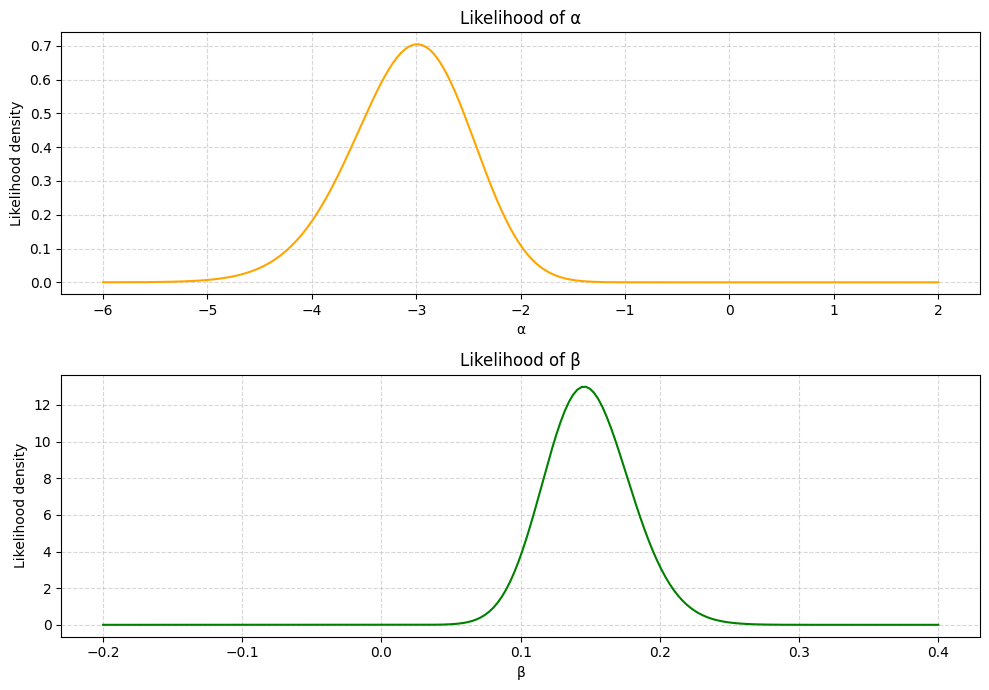

In [86]:
lik_alpha = np.sum(L, axis=0) 
lik_beta = np.sum(L, axis=1)  

d_alpha = alpha_range[1] - alpha_range[0]
d_beta = beta_range[1] - beta_range[0]

lik_alpha_norm = lik_alpha / (np.sum(lik_alpha) * d_alpha)
lik_beta_norm = lik_beta / (np.sum(lik_beta) * d_beta)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(alpha_range, lik_alpha_norm, color='orange')
axes[0].set_title("Likelihood of α")
axes[0].set_xlabel("α")
axes[0].set_ylabel("Likelihood density")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(beta_range, lik_beta_norm, color='green')
axes[1].set_title("Likelihood of β")
axes[1].set_xlabel("β")
axes[1].set_ylabel("Likelihood density")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Notably, the posterior for $\beta$ has moved entirely into positive territory, confirming that higher temperatures increase spoilage rates.

In [87]:
from scipy.optimize import minimize

# Initial guess (from visual inspection)
theta_init = np.array([-3.0, 0.15])

# Optimization
result = minimize(
    neg_log_likelihood,
    theta_init,
    args=(x, n, y),
    method='BFGS'
)

# ML estimates
alpha_ML, beta_ML = result.x
print(f"ML Estimates:")
print(f"α_ML = {alpha_ML:.4f}")
print(f"β_ML = {beta_ML:.4f}")
print(f"Log-likelihood at MLE: {-result.fun:.4f}")

ML Estimates:
α_ML = -2.9776
β_ML = 0.1439
Log-likelihood at MLE: -48.9011


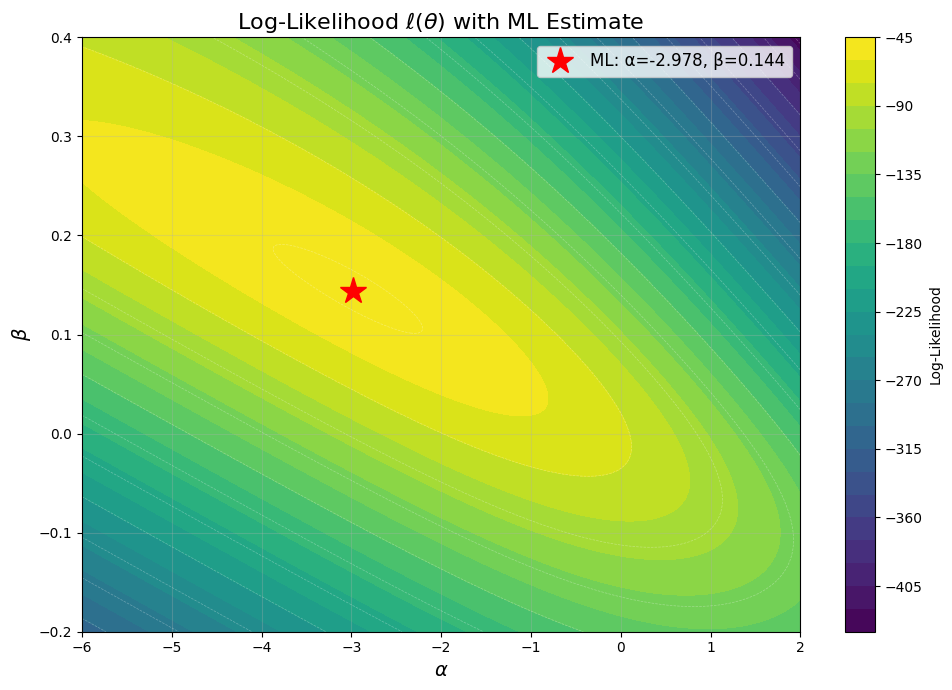

In [88]:
# Plot log-likelihood with ML estimate
fig, ax = plt.subplots(figsize=(10, 7))

# Contour plot
contour = ax.contourf(Alpha, Beta, LL, levels=30, cmap='viridis')
ax.contour(Alpha, Beta, LL, levels=15, colors='white', alpha=0.3, linewidths=0.5)

# ML estimate
ax.plot(alpha_ML, beta_ML, 'r*', markersize=20, label=f'ML: α={alpha_ML:.3f}, β={beta_ML:.3f}')

ax.set_xlabel(r'$\alpha$', fontsize=14)
ax.set_ylabel(r'$\beta$', fontsize=14)
ax.set_title(r'Log-Likelihood $\ell(\theta)$ with ML Estimate', fontsize=16)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.colorbar(contour, ax=ax, label='Log-Likelihood')
plt.tight_layout()
plt.show()

## 1.3 Maximum a Posteriori (MAP) Estimation

- Derive an analytical expression of the posterior $f(\theta | y)$, up to a multiplicative factor not depending on 𝜃.
Hint: exploit the already-obtained likelihood and the known functional form of the Gaussian pdf.
- Derive an analytical expression of the log-posterior $g(\theta) = f(\theta | y)$, up to an additive factor not depending on $\theta$.
- Write the unnormalized log-posterior (up to a multiplicative/additive factor, respectively) as Python functions.
- Compute the maximum a posteriore estimates $\alpha^{MAP}$, $\beta^{MAP}$
- Visualize the MAP and the ML estimate together with the unnormalized posterior in 2D. Comment the results

### 1.3.1 Analytical expression of the Posterior $f(\theta \mid y)$


The analytical expression for the (unnormalized) posterior probability follows directly from Bayes' theorem:

$$
f(\theta \mid y) \propto \mathcal{L}(\theta) \cdot f(\theta)
$$

Where:

**Likelihood** $\mathcal{L}(\theta) = P(y \mid \theta)$ so we have:

$$
\mathcal{L}(\theta) \propto \prod_{i=1}^{4} p_i^{y_i} (1 - p_i)^{n_i - y_i}
$$

**Prior:** $f(\theta) = f(\alpha) \cdot f(\beta)$ so we have:

$$
f(\theta) \propto \exp\Bigg(-\frac{(\alpha - \mu_{\alpha})^2}{2 \sigma_{\alpha}^2} - \frac{(\beta - \mu_{\beta})^2}{2 \sigma_{\beta}^2}\Bigg)
$$


Substituting the mean and standard deviation values for the priors ($\mu_{\alpha}=0, \sigma_{\alpha}=2, \mu_{\beta}=0, \sigma_{\beta}=1$) we obtain:

$$
f(\theta \mid y) \propto \left[ \prod_{i=1}^{4} p_i^{y_i} (1 - p_i)^{n_i - y_i} \right] \cdot \exp\Big(-\frac{\alpha^2}{8} - \frac{\beta^2}{2}\Big)
$$

where

$$
p_i = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}.
$$


###  1.3.2 Analytical expression of the Log-Posterior $g(\theta)$

$$
g(\theta) = \log f(\theta \mid y) = \log \mathcal{L}(\theta) + \log f(\theta) + \text{const}
$$

Using the previously derived expressions (omitting additive constants that do not depend on $\theta$):

**Log-Likelihood** $\ell(\theta) = \log \mathcal{L}(\theta)$:

$$
\ell(\theta) \propto \sum_{i=1}^{4} \Big[ y_i \log p_i + (n_i - y_i) \log(1 - p_i) \Big]
$$

**Log-Prior** $\log f(\theta)$:

$$
\log f(\theta) \propto -\frac{\alpha^2}{8} - \frac{\beta^2}{2}
$$

The final expression of the log-posterior (up to an additive constant) is:

$$
g(\theta) \propto \sum_{i=1}^{4} \Big[ y_i \log p_i + (n_i - y_i) \log(1 - p_i) \Big] - \frac{\alpha^2}{8} - \frac{\beta^2}{2}
$$

where

$$
p_i = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}.
$$


### 1.3.3 Python Function for un-normalized log-posterior

In [89]:
def log_posterior(theta, x, n, y):
    alpha, beta = theta

    log_prior_alpha = stats.norm.logpdf(alpha, loc=0, scale=2)
    log_prior_beta = stats.norm.logpdf(beta, loc=0, scale=1)
    log_prior = log_prior_alpha + log_prior_beta
    
    # Log-likelihood
    log_lik = log_likelihood(theta, x, n, y)
    
    # Log-posterior 
    log_post = log_prior + log_lik
    return log_post

def neg_log_posterior(theta, x, n, y):
    return -log_posterior(theta, x, n, y)

### 1.3.4 Compute the maximum a posteriore estimates $\alpha^{MAP}$, $\beta^{MAP}$

In [90]:
# Initial guess (from ML estimates)
theta_init_map = np.array([-3.0, 0.2])

# Optimization
result_map = minimize(neg_log_posterior,theta_init_map,args=(x, n, y),method='BFGS')

# MAP estimates
alpha_MAP, beta_MAP = result_map.x
print(f"MAP Estimates:")
print(f"α_MAP = {alpha_MAP:.4f}")
print(f"β_MAP = {beta_MAP:.4f}")

MAP Estimates:
α_MAP = -2.7707
β_MAP = 0.1338


### 1.3.5. Visualize the MAP and the ML estimate together with the unnormalized posterior in 2D. Comment the results

In [91]:
def log_prior(A,B,mu_alpha,sigma_alpha,mu_beta,sigma_beta):
    return -0.5 * (((A - mu_alpha) / sigma_alpha) ** 2 + ((B - mu_beta) / sigma_beta) ** 2)

In [92]:
log_prior = log_prior(Alpha, Beta, 0, 2, 0, 1)
# Compute log-posterior on grid
log_post = LL
post = np.exp(log_post - np.max(log_post))

In [93]:
alpha_vec = np.linspace(alpha_MAP - 1.3, alpha_MAP + 1.3, 100)
beta_vec = np.linspace(beta_MAP - 0.1, beta_MAP + 0.1, 100)
Alpha_grid, Beta_grid = np.meshgrid(alpha_vec, beta_vec)

z_posterior = np.zeros_like(Alpha_grid)
for i in range(Alpha_grid.shape[0]):
    for j in range(Alpha_grid.shape[1]):
        z_posterior[i, j] = log_posterior([Alpha_grid[i, j], Beta_grid[i, j]], x, n, y)
        
UP_norm = np.exp(z_posterior - np.max(z_posterior))

In [94]:
fig = go.Figure()

fig.add_trace(go.Contour(z=UP_norm, x=alpha_vec, y=beta_vec,colorscale='Viridis',name='Posterior Density'))

# ML Values
fig.add_trace(go.Scatter(x=[alpha_ML], y=[beta_ML], mode='markers', marker=dict(color='red', size=12, symbol='x'), name='ML Estimate', showlegend=False))
# MAP Values
fig.add_trace(go.Scatter(x=[alpha_MAP], y=[beta_MAP], mode='markers', marker=dict(color='blue', size=12, symbol='circle'), name='MAP Estimate', showlegend=False))

fig.update_layout(title = "Unnormalized Posterior Density with ML and MAP Estimates",xaxis_title='Alpha',yaxis_title='Beta',width= 900, height=700)
fig.show()

The comparison between the Maximum Likelihood Estimate and the Maximum Aposteriori estimate illustrates the influence of our prior knowledge on the final results as the ML estimate focuses solely on the observed data while the MAP estimate represents a compromise between the data and our prior distributions.

## 1.4 Brute-force posterior estimation

- Compute a gridding approximation of the normalized posterior.
    - Use logarithm transformations for better numerical stability.
- Compute the marginal posterior distributions of $\alpha$ and $\beta$ from the gridding approximation.
- Using the grid-based approximation of the posterior, compute the posterior mean of $\alpha$ and $\beta$.

In [95]:
z_posterior = np.zeros_like(Alpha)
for i in range(Alpha.shape[0]):
    for j in range(Alpha.shape[1]):
        z_posterior[i, j] = log_posterior([Alpha[i, j], Beta[i, j]], x, n, y)
        
UP_norm = np.exp(z_posterior - np.max(z_posterior))

In [96]:
c = np.sum(UP_norm)
normalized_posterior = UP_norm / c

In [97]:
print(f"Constant of normalizzazion c: {c:.4e}")
print(f"Verify sum = 1: {np.sum(normalized_posterior):.10f}")

Constant of normalizzazion c: 3.6261e+02
Verify sum = 1: 1.0000000000


Now we can perform the discrete marginalization of the joint posterior to obtain the marginal posterior distributions for $\alpha$ and $\beta$.

$$ P(\alpha | y) = \int P(\alpha, \beta | y) d\beta \approx \sum_{j} P(\alpha, \beta_j | y) \Delta \beta $$

$$P(\beta | y) = \int P(\alpha, \beta | y) d\alpha \approx \sum_{i} P(\alpha_i, \beta | y) \Delta \alpha $$

Where $\Delta \alpha$ and $\Delta \beta$ are the grid step sizes for $\alpha$ and $\beta$, respectively.

In [98]:
marginal_alpha_unnorm = np.sum(UP_norm, axis=0) 
marginal_beta_unnorm = np.sum(UP_norm, axis=1)

And finally we can normalize the marginals:
$$ p(\alpha | y) = \frac{P(\alpha | y)}{\sum_{i} P(\alpha_i | y) \Delta \alpha} $$
$$ p(\beta | y) = \frac{P(\beta | y)}{\sum_{j} P(\beta_j | y) \Delta \beta} $$

In [99]:
#to compute density marginals we need the step sizes and sums over axes
d_alpha = alpha_range[1] - alpha_range[0]
d_beta = beta_range[1] - beta_range[0]

marginal_alpha = marginal_alpha_unnorm / (np.sum(marginal_alpha_unnorm) * d_alpha)
marginal_beta = marginal_beta_unnorm / (np.sum(marginal_beta_unnorm) * d_beta)

In [100]:
#marginal_alpha = np.sum(normalized_posterior, axis=0)
#marginal_beta  = np.sum(normalized_posterior, axis=1)

# print(f"Marginal posterior for alpha: {marginal_alpha}")
# print(f"Marginal posterior for beta: {marginal_beta}")

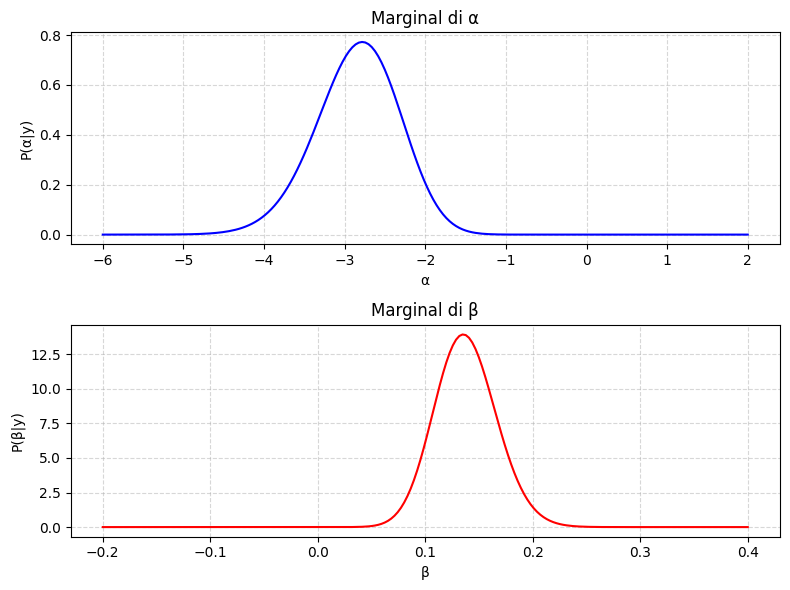

In [101]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# Marginal di alpha
axes[0].plot(alpha_range, marginal_alpha, color='blue')
axes[0].set_title('Marginal di α')
axes[0].set_xlabel('α')
axes[0].set_ylabel('P(α|y)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Marginal di beta
axes[1].plot(beta_range, marginal_beta, color='red')
axes[1].set_title('Marginal di β')
axes[1].set_xlabel('β')
axes[1].set_ylabel('P(β|y)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 1.5 Metropolis

- Obtain a sample-based approximation of the posterior $f(\theta| y)$ by implementing the Metropolis algorithm from scratch.
    - Use logarithm transformation for better numerical robustness.
    - Remove the first 1000 samples (they depend on the initial conditions; this is the burn-in period)
    - Run multiple chains and compare visually the posterior distribution provided by the different chains. Do they overlap well?
    - Inspect the trace. Does it show a strong correlation? Which is the rate of acceptance (aim at 50%)?
    - Ajust the algorithm settings if needed, and show how the sampling performs before and after the adjustment.
- Compare the Metropolis samples with the gridding-based approximation of the posterior
distribution $f(\theta| y)$ and comment the result.


As we saw, to obtain the posterior distribution $ f_{post}(\theta) = f(\theta | y) = K f_{prior}(\theta) \mathcal{L}(\theta)$. This means that we can evaluate the posterior up to a normalizing constant $K$. This is sufficient for implementing the Metropolis algorithm, which only requires the ability to compute the unnormalized posterior density at any point $\theta$.

The Metropolis algorithm only needs to compute **ratios** of posterior densities:

$$ ratio = \frac{f(\theta^* | y)}{f(\theta^{(t-1)} | y)} = \frac{K \cdot f(\theta^*) \cdot \mathcal{L}(\theta^*)}{K \cdot f(\theta^{(t-1)}) \cdot \mathcal{L}(\theta^{(t-1)})} = \frac{f(\theta^*) \cdot \mathcal{L}(\theta^*)}{f(\theta^{(t-1)}) \cdot \mathcal{L}(\theta^{(t-1)})}$$

the constant $K$ (where $K = \frac{1}{P(y)}$) cancels out. Therefore, we only need to compute:

$$f(\theta|y) \propto \mathcal{L}(\theta) \cdot f(\theta)$$

which we already derived in sections 1.1 and 1.3.



### 1.5.1 Metropolis Algorithm Implementation from Scratch


#### Metropolis Algorithm Steps

For our mushroom spoilage problem with $\theta = [\alpha, \beta]^{\top}$:

**1. Initialization:**
- Choose starting values $\theta^{(0)} = [\alpha^{(0)}, \beta^{(0)}]^{\top}$
- Set proposal distribution: $q(\theta^* | \theta^{(t)}) = \mathcal{N}(\theta^{(t)}, \Sigma)$
  where $\Sigma = \begin{bmatrix} \sigma_\alpha^2 & 0 \\ 0 & \sigma_\beta^2 \end{bmatrix}$ is the proposal covariance matrix

**2. Iteration** (for $t = 1, 2, \ldots, N$):

**Step a) Propose new state:**
$$\theta^* \sim \mathcal{N}(\theta^{(t-1)}, \Sigma)$$

**Step b) Compute acceptance ratio:**
$$r = \frac{f(\theta^* | y)}{f(\theta^{(t-1)} | y)} = \frac{\mathcal{L}(\theta^*) \cdot f(\theta^*)}{\mathcal{L}(\theta^{(t-1)}) \cdot f(\theta^{(t-1)})}$$

In **log-space** (for numerical stability):
$$\log r = \log f(\theta^* | y) - \log f(\theta^{(t-1)} | y)$$

we found that:
$$\log r = [\log \mathcal{L}(\theta^*) + \log f(\theta^*)] - [\log \mathcal{L}(\theta^{(t-1)}) + \log f(\theta^{(t-1)})]$$

and expanding the terms:
$$\log r = \underbrace{\left[\sum_{i=1}^{4} y_i \log p_i^* + (n_i - y_i) \log(1-p_i^*)\right]}_{\text{Log-likelihood at } \theta^*} \underbrace{- \frac{(\alpha^*)^2}{8} - \frac{(\beta^*)^2}{2}}_{\text{Log-prior at } \theta^*}$$
$$- \underbrace{\left[\sum_{i=1}^{4} y_i \log p_i^{(t-1)} + (n_i - y_i) \log(1-p_i^{(t-1)})\right]}_{\text{Log-likelihood at } \theta^{(t-1)}} \underbrace{+ \frac{(\alpha^{(t-1)})^2}{8} + \frac{(\beta^{(t-1)})^2}{2}}_{\text{Log-prior at } \theta^{(t-1)}}$$

where $p_i^* = \frac{1}{1 + e^{-(\alpha^* + \beta^* x_i)}}$ and $p_i^{(t-1)} = \frac{1}{1 + e^{-(\alpha^{(t-1)} + \beta^{(t-1)} x_i)}}$.

**Step c) Accept/Reject:**
- Compute acceptance probability: $\alpha = \min(1, r)$
- Generate $u \sim \text{Uniform}(0, 1)$
- If $u < \alpha$: accept $\theta^{(t)} = \theta^*$
- Else: reject $\theta^{(t)} = \theta^{(t-1)}$

**3. Output:**
After burn-in period (first $B$ samples), the remaining samples $\{\theta^{(B+1)}, \ldots, \theta^{(N)}\}$ approximate the posterior distribution.


In [ ]:
# 1 Initialization
# std(alpha) = ( 0.3-0.5 ) * 0.3 = 0.01     
# std(beta) = ( 0.03-0.05 ) * 0.3 = 0.001
# I have already defined x, n, y above

cov_matrix = np.array([[0.01, 0],
                       [0, 0.001]])

n_samples = 50000
start_theta = np.array([0.0, 0.0])
samples = []

In [103]:
def metropolis_chain(start_theta, n_samples, cov_matrix, x, n, y):
    samples = np.zeros((n_samples, 2))
    theta = start_theta.copy()
    accepted = 0

    for i in range(n_samples):
        samples[i] = theta

        proposal = theta + np.random.multivariate_normal(mean=[0, 0], cov=cov_matrix)

        log_r = (log_posterior(proposal, x, n, y) - log_posterior(theta, x, n, y))

        if log_r > 0 or np.random.rand() < np.exp(log_r):
            theta = proposal
            accepted += 1

    acceptance_rate = accepted / n_samples
    return samples, acceptance_rate


In [ ]:
n_samples = 50000
burn_in = 1000

initial_points = [
    np.array([0.0, 0.0]),
    np.array([1.0, 0.1]),
    np.array([-1.0, -0.1])
]

chains = []
acceptance_rates = []

for i, start in enumerate(initial_points):
    samples, acc_rate = metropolis_chain(start, n_samples, cov_matrix, x, n, y)
    chains.append(samples)
    acceptance_rates.append(acc_rate)
    print(f"Chain {i+1} acceptance rate: {acc_rate:.2%}")

Chain 1 acceptance rate: 44.32%
Chain 2 acceptance rate: 43.92%
Chain 3 acceptance rate: 44.34%


In [ ]:
def hdi(samples, cred_mass=0.95):
    sorted_samples = np.sort(samples)
    n_samples = len(sorted_samples)
    interval_idx_inc = int(np.floor(cred_mass * n_samples))
    n_intervals = n_samples - interval_idx_inc
    intervals = sorted_samples[interval_idx_inc:] - sorted_samples[:n_intervals]
    min_idx = np.argmin(intervals)
    hdi_min = sorted_samples[min_idx]
    hdi_max = sorted_samples[min_idx + interval_idx_inc]
    return hdi_min, hdi_max

In [ ]:
n_chains = 3
last_n, first_n = 1000, 1000

def plot_chain(param='alpha'):
    plt.close('all')
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=False)

    idx = 0 if param == 'alpha' else 1  
    for i in range(n_chains):
        chain = chains[i][:, idx]
        x_min, x_max = chain.min(), chain.max()

        axes[0, i].hist(chain[burn_in:], bins=50, density=True)
        axes[0, i].set_title(f"Chain {i+1} – Posterior {param}")
        axes[0, i].set_xlabel(param)
        axes[0, i].set_ylabel("Density")
        axes[0, i].grid(True, linestyle='--', alpha=0.5)

        hdi_min, hdi_max = hdi(chain[burn_in:])
        axes[0, i].axvline(hdi_min, color='red', linestyle='--', label='95% HDI')
        axes[0, i].axvline(hdi_max, color='red', linestyle='--')
        axes[0, i].legend()

        axes[1, i].plot(chain[-last_n:], range(n_samples - last_n, n_samples), linewidth=1)
        axes[1, i].set_title("End of chain (last 1000)")
        axes[1, i].set_xlabel(param)
        axes[1, i].set_ylabel("Iteration")
        axes[1, i].grid(True, linestyle='--', alpha=0.5)
        axes[1, i].set_xlim(x_min, x_max)

        axes[2, i].plot(chain[:first_n], range(first_n), linewidth=1)
        axes[2, i].set_title("Beginning of chain (first 1000)")
        axes[2, i].set_xlabel(param)
        axes[2, i].set_ylabel("Iteration")
        axes[2, i].grid(True, linestyle='--', alpha=0.5)
        axes[2, i].set_xlim(x_min, x_max)  

    plt.tight_layout()
    plt.show()

interact(plot_chain, param=['alpha', 'beta'])


interactive(children=(Dropdown(description='param', options=('alpha', 'beta'), value='alpha'), Output()), _dom…

<function __main__.plot_chain(param='alpha')>

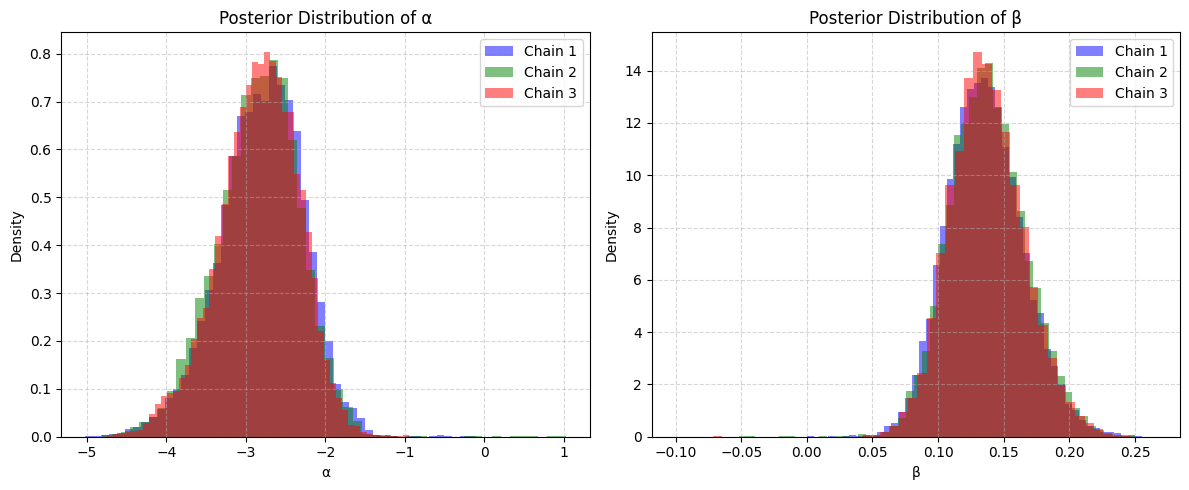

In [107]:
colors = ['blue', 'green', 'red']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(n_chains):
    chain = chains[i][:, 0]  
    axes[0].hist(chain, bins=50, density=True, color=colors[i], alpha=0.5, label=f'Chain {i+1}')
axes[0].set_title('Posterior Distribution of α')
axes[0].set_xlabel('α')
axes[0].set_ylabel('Density')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()


for i in range(n_chains):
    chain = chains[i][:, 1]
    axes[1].hist(chain, bins=50, density=True, color=colors[i], alpha=0.5, label=f'Chain {i+1}')
axes[1].set_title('Posterior Distribution of β')
axes[1].set_xlabel('β')
axes[1].set_ylabel('Density')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

In [108]:
samples_burned = np.vstack([chain[burn_in:, :] for chain in chains])
print(samples.shape)  

(50000, 2)


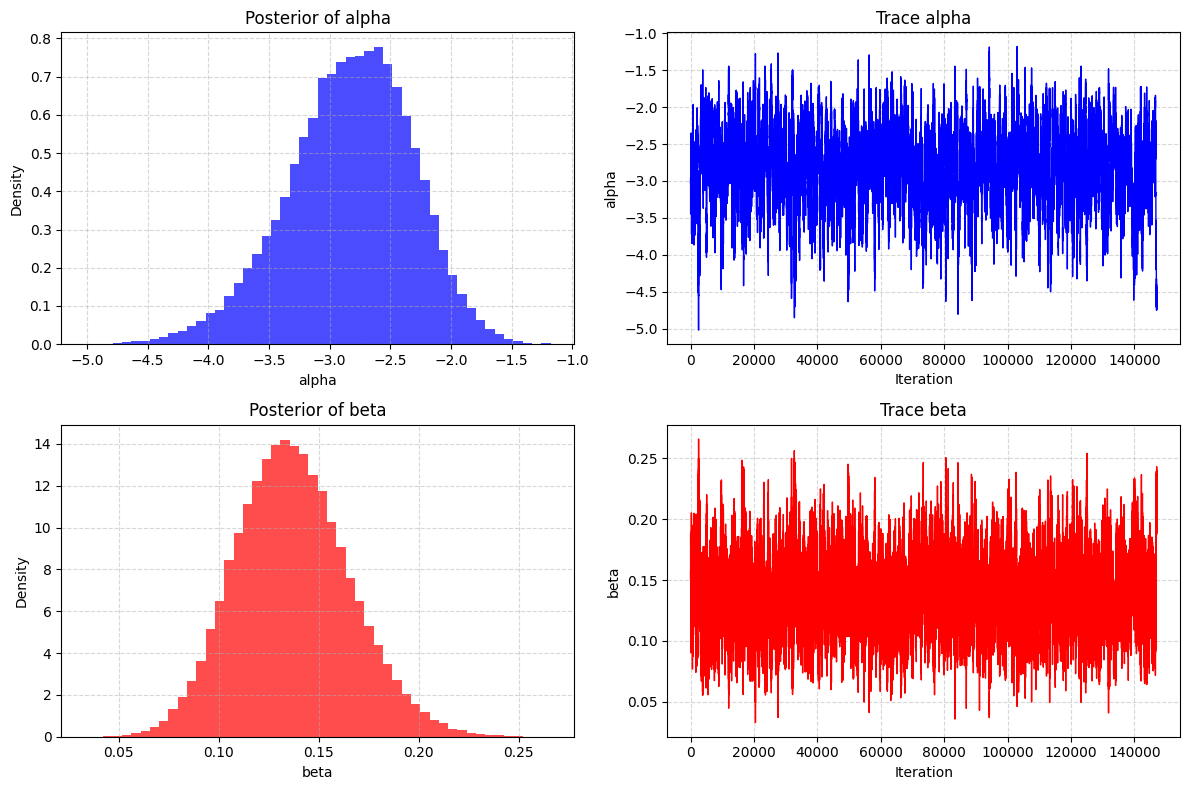

In [109]:
import matplotlib.pyplot as plt

params = ['alpha', 'beta']
colors = ['blue', 'red']
titles = ['Posterior', 'Trace']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, param in enumerate(params):
    axes[i, 0].hist(samples_burned[:, i], bins=50, density=True, color=colors[i], alpha=0.7)
    axes[i, 0].set_title(f"Posterior of {param}")
    axes[i, 0].set_xlabel(param)
    axes[i, 0].set_ylabel("Density")
    axes[i, 0].grid(True, linestyle='--', alpha=0.5)
    
    axes[i, 1].plot(samples_burned[:, i], color=colors[i], linewidth=1)
    axes[i, 1].set_title(f"Trace {param}")
    axes[i, 1].set_xlabel("Iteration")
    axes[i, 1].set_ylabel(param)
    axes[i, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 1.5.2 Compare the Metropolis samples with the gridding-based approximation of the posterior

$$ prior : f_{prior}(\theta) = f(\alpha) \cdot f(\beta)  \propto exp (-\frac{\alpha^2}{8} - \frac{\beta^2}{2}) \\
likelihood : \mathcal{L}(\theta) = P(y | \theta) = \prod_{i=1}^{4} \left[ \binom{n_i}{y_i} p_i^{y_i} (1-p_i)^{n_i - y_i} \right] \\
posterior : f_{post}(\theta) = f(\theta | y) \propto f_{prior}(\theta) \cdot \mathcal{L}(\theta)
$$

In [110]:
# fig, ax = plt.subplots(figsize=(10, 8))

# # Grid-based posterior (contours)
# contour = ax.contourf(Alpha_grid, Beta_grid, normalized_posterior, 
#                       levels=20, cmap='Blues', alpha=0.7)
# ax.contour(Alpha_grid, Beta_grid, normalized_posterior, 
#            levels=10, colors='blue', linewidths=1.5)

# # Metropolis samples (scatter)
# ax.scatter(samples_burned[:, 0], samples_burned[:, 1], 
#            s=1, alpha=0.3, color='red', label='Metropolis samples')

# # MAP estimate
# ax.plot(alpha_MAP, beta_MAP, 'g*', markersize=15, label='MAP')

# ax.set_xlabel(r'$\alpha$', fontsize=14)
# ax.set_ylabel(r'$\beta$', fontsize=14)
# ax.set_title('Joint Posterior: Metropolis (red) vs Grid (blue)', fontsize=16)
# ax.legend(fontsize=12)
# plt.colorbar(contour, ax=ax, label='Grid Posterior Density')
# plt.tight_layout()
# plt.show()

In [111]:
fig = go.Figure()

# 1. Grid-based posterior (contour)
fig.add_trace(go.Contour(
    z=normalized_posterior, 
    x=alpha_range, 
    y=beta_range,
    colorscale='Blues',
    name='Grid Posterior',
    showscale=True,
    contours=dict(
        start=0,
        end=normalized_posterior.max(),
        size=normalized_posterior.max()/20
    ),
    colorbar=dict(len = 0.9,y=0.4)
))

# 2. Metropolis samples (scatter with low opacity)
fig.add_trace(go.Scatter(
    x=samples_burned[:, 0], 
    y=samples_burned[:, 1], 
    mode='markers',
    marker=dict(color='red', size=2, opacity=0.3),
    name='Metropolis samples'
))

# 3. MAP estimate for reference
fig.add_trace(go.Scatter(
    x=[alpha_MAP], 
    y=[beta_MAP], 
    mode='markers', 
    marker=dict(color='green', size=15, symbol='star'),
    name='MAP Estimate'
))

fig.update_layout(
    title="Joint Posterior: Metropolis Samples (red) vs Grid Approximation (blue)",
    xaxis_title='α',
    yaxis_title='β',
    width=900, 
    height=700,
    showlegend=True,
    xaxis_range=[alpha_MAP - 1.3, alpha_MAP + 1.3],
    yaxis_range=[beta_MAP - 0.1, beta_MAP + 0.1]
)

fig.show()

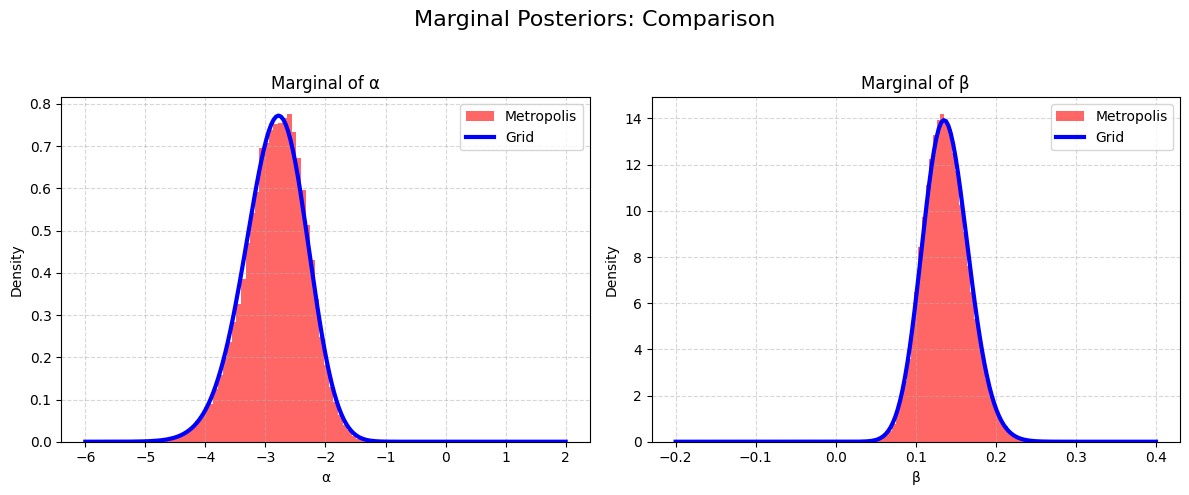

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(samples_burned[:, 0], bins=50, density=True, color='red', alpha=0.6, label='Metropolis')
axes[0].plot(alpha_range, marginal_alpha, color='blue', linewidth=3, label='Grid')
axes[0].set_title('Marginal of α')
axes[0].set_xlabel('α')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)


axes[1].hist(samples_burned[:, 1], bins=50, density=True, color='red', alpha=0.6, label='Metropolis')
axes[1].plot(beta_range, marginal_beta, color='blue', linewidth=3, label='Grid')
axes[1].set_title('Marginal of β')
axes[1].set_xlabel('β')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Marginal Posteriors: Comparison', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### comment results

## Extra

We were interested also in understanding how the model performs in predicting the spoilage probability at different temperatures and how uncertainty in parameter estimates translates into uncertainty in predictions. Our model is working properly or do we need to improve it?

### 1.5.3: Model Validation

In [113]:
# Posterior predictive curves (similar to prior predictive check)
n_posterior_samples = 200
temp_range = np.linspace(-5, 40, 100)

fig = go.Figure()

# Sample from posterior and plot curves
for i in range(n_posterior_samples):
    # Sample random (alpha, beta) from MCMC posterior
    idx = np.random.randint(len(samples_burned))
    alpha_sample, beta_sample = samples_burned[idx]
    
    # Compute predicted probability
    p_pred = sigmoid(alpha_sample + beta_sample * temp_range)
    
    fig.add_trace(go.Scatter(
        x=temp_range,
        y=p_pred,
        mode='lines',
        line=dict(color='blue', width=1),
        opacity=0.15,
        showlegend=(i==0),
        name='Posterior Predictive',
        hovertemplate=(
            f"α: {alpha_sample:.2f}<br>" +
            f"β: {beta_sample:.3f}<br>" +
            "Temp: %{x:.1f}°C<br>" +
            "Prob: %{y:.2%}"
        )
    ))

# Add observed data points
fig.add_trace(go.Scatter(
    x=x,
    y=real_proportion,
    mode='markers',
    marker=dict(color='red', size=12, line=dict(width=2, color='white')),
    name='Observed Data',
    hovertemplate="Observed: %{y:.2%}<br>" + "Temp: %{x}°C"
))

#Add mean posterior predictive curve
mean_alpha = np.mean(samples_burned[:, 0])
mean_beta = np.mean(samples_burned[:, 1])
mean_p_pred = sigmoid(mean_alpha + mean_beta * temp_range)
fig.add_trace(go.Scatter(
    x=temp_range,
    y=mean_p_pred,
    mode='lines',
    line=dict(color='black', width=3, dash='dash'),
    name='Mean Posterior Predictive',
    hovertemplate="Mean Posterior Predictive<br>" + "Temp: %{x:.1f}°C<br>" + "Prob: %{y:.2%}"
))

# Add reference line at 50%
fig.add_hline(y=0.5, line_dash="dash", line_color="gray", opacity=0.5)

fig.update_layout(
    title="Posterior Predictive Check: Spoilage Probability Curves",
    xaxis_title="Temperature (°C)",
    yaxis_title="Probability of Spoilage",
    width=1000,
    height=600,
    showlegend=True
)

fig.show()

This plot visualizes the **Posterior Predictive Distribution**, allowing us to evaluate how well our Bayesian model captures the relationship between temperature and spoilage probability. As we can observe, when we take all the sigmoid distributions sampled from our posterior and analyze their mean, the resulting curve aligns very closely with our real data points. This proximity serves as a strong indicator that the posterior distribution is well-calibrated and effectively represents the observed reality. Furthermore, the fact that all possible sigmoid curves are tightly clustered together demonstrates that the model is highly confident in its estimates. This stands in stark contrast to the Prior Predictive Check, where the curves were widely dispersed due to initial uncertainty; here, the tight convergence confirms that the data has successfully informed the model, reducing uncertainty to a narrow, reliable range.

In [114]:
#alpha_range = np.linspace(-10, 10, 400)
#beta_range = np.linspace(-2, 2, 400)

In [115]:
prior_alpha = scipy.stats.norm.pdf(alpha_range, loc=0, scale=2)
#already done in likelihood computation
#d_alpha = alpha_range[1] - alpha_range[0]
#lik_alpha_unnorm = np.sum(L, axis=0)
#likelihood_alpha =lik_alpha_unnorm / (np.sum(lik_alpha_unnorm) * d_alpha)

In [116]:
prior_beta = scipy.stats.norm.pdf(beta_range, loc=0, scale=1)
#already done in likelihood computation
#d_beta = beta_range[1] - beta_range[0]
#lik_beta_unnorm = np.sum(L, axis=1)      
#likelihood_beta = lik_beta_unnorm / (np.sum(lik_beta_unnorm) * d_beta)

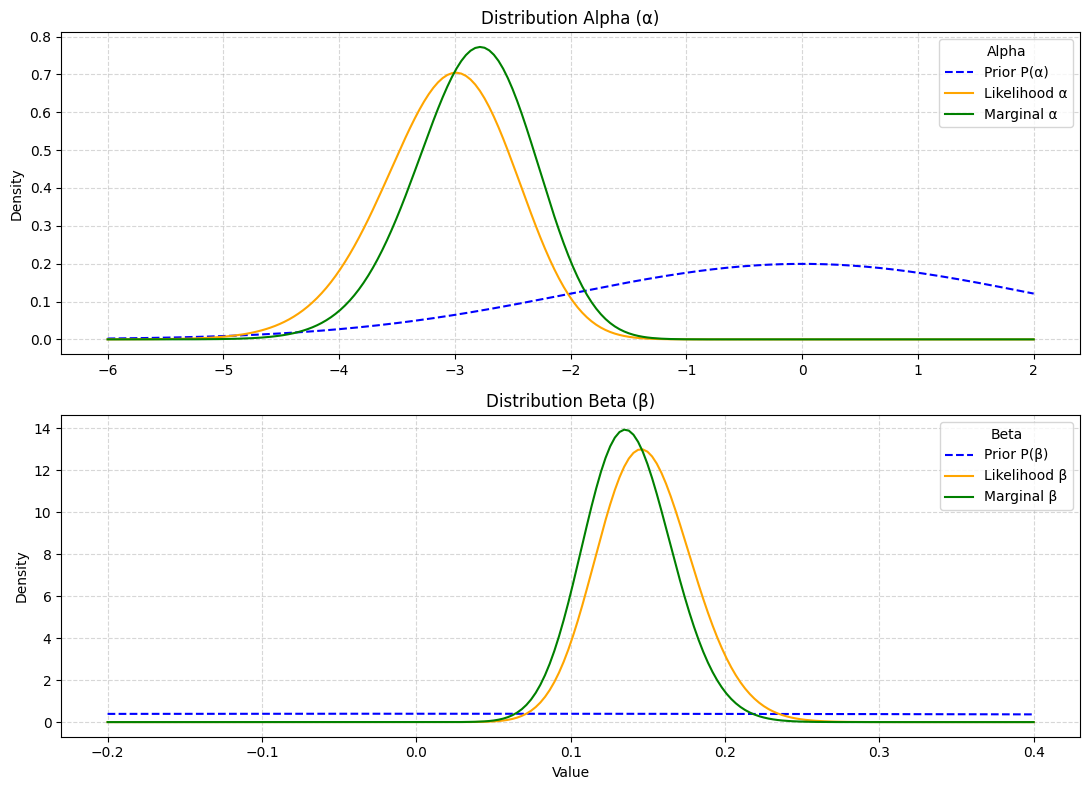

In [117]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

axes[0].plot(alpha_range, prior_alpha, label='Prior P(α)', color='blue', linestyle='--')
axes[0].plot(alpha_range, lik_alpha_norm, label='Likelihood α', color='orange')
axes[0].plot(alpha_range, marginal_alpha, label='Marginal α', color='green')
axes[0].set_title("Distribution Alpha (α)")
axes[0].set_ylabel("Density")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right', title="Alpha")

axes[1].plot(beta_range, prior_beta, label='Prior P(β)', color='blue', linestyle='--')
axes[1].plot(beta_range, lik_beta_norm, label='Likelihood β', color='orange')
axes[1].plot(beta_range, marginal_beta, label='Marginal β', color='green')
axes[1].set_title("Distribution Beta (β)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right', title="Beta")

plt.tight_layout()
plt.show()

From this image, the effect of likelihood on prior is evident for parameter $\alpha$: the posterior is in fact an intermediate distribution between prior and likelihood, more concentrated in the region supported by the data but still influenced by prior information.

The same behaviour is also observed for $\beta$: starting from an uninformative prior, modelled as a normal distribution with mean 0 and standard deviation 1, the likelihood guides the Bayesian update and the posterior shifts and narrows with respect to the prior, reflecting the evidence provided by the data.

## Da fare

1. Add multiple chain for montecarlo, per ora stiamo usando una singola chain